## Numerical Solution of Second-Order ODEs
Spring-Mass System: Suspension of a 2003 Volkswagen Beetle

### 1. Introduction & Model Selection

This project intends to model the oscillations of a vehicle suspension 
system as a spring-mass system through the implementation of Forward Euler's and Fourth-Order Runge-Kutta methods. The chosen subject is the 2003 Volkswagen Beetle, and I will be considering the displacement of the coils in the suspension when driving over a speed bump. The second-order ordinary differential equation (ODE) of a spring-mass system is

$$m \frac{d^2 y}{dt_2} + c \frac{dy}{dt} + ky = 0$$

where $m$ is the mass of the vehicle in kilograms, $c$ is the damping coefficient in Newton seconds per meter, $k$ is the spring constant in Newtons per meter, and the function $y(t)$ represents the displacement from the equilibrium in meters; the equilibrium point is defined where the suspension coil is neither compressed nor stretched.
Deriving the second-order differential equation into two first-order ODEs gives

$$\frac{dy_1}{dt} = y_2$$
$$\frac{dy_2}{dt} = -\frac{c}{m}y_2 -\frac{k}{m}y_1$$

which I will use to implement the Forward Euler's (FE) and Fourth-Order Runge-Kutta (RK4) methods.

### 2. Parameter Research

Assuming no passengers are in the vehicle, the mass of the car is 1292 kilograms (*Volkswagen NEW Beetle*, 2026). The damping coefficient for the suspension system can be found from the equation
$$c = 2\zeta \sqrt{mk}$$

According to Hyun, “damping ratios $\zeta$ = 0.2 and 0.5…typify the bounds on the damping ratio in most passenger cars,” and for this application, I will assume $\zeta$ = 0.3 (Hyun, p. 93, 2005; Avi, 2021). I find that the damping coefficient $c$ = 4242.658. The 2003 Volkswagen Beetle uses spring struts, also called MacPherson struts, for the front suspension which have a spring constant of 38700 N/m, assuming the material of the spring is “SAE 9254 spring steel,” which is commonly used for this vehicle model (*2003 Volkswagen Beetle Specifications*, 2019; Dodamani et al., 2016).

For a scenario in which the vehicle slowly goes over a speed bump “with a length of 0.45m and height of 0.06m” (Hyun, p. 31, 2005), $t = 0$ is the point when the suspension coil is compressed by the weight of the car and the upward force from the speed bump; this maximum displacement is equal to the height of the bump: 0.06 meters (p. 31).

*Table 1*: **Parameters for Spring-Mass System** $^{(1)}$

| variable | value | source |
|:---:|:---:|:---:|
|mass $(m)$ | 1292 kg | *Volkswagen NEW Beetle* (Auto-data, 2026)|
|damping coefficient $(c)$ | 4242.658 Ns/m | *Effect of Suspension Damping* (Hyun, 2025)|
|spring constant $(k)$ | 38700 N/m | *2003 Volkswagen Beetle Specifications*, (TheCarConnection, 2019)|
|$y(t)$ (displacement) | 0.06 m | *Effect of Suspension Damping* (Hyun, 2025)|

### 3. Numerical Methods Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Euler's Forward Method (FE)
def forward_euler(f, y10, y20, t0, tf, h):
    
    # array for time steps
    t = np.arange(t0, tf + h, h)
    y1 = np.zeros_like(t)
    y2 = np.zeros_like(t)
    
    # initial conditions
    y1[0] = y10
    y2[0] = y20

    for i in range(len(t)-1):
        y1[i+1] = y1[i] + h * y2[i] # f_1 = y_2
        y2[i+1] = y2[i] + h * f(t[i], y1[i], y2[i])
    
    return t, y1, y2 # returning values of time (t), position function (y1) and velocity function (y2)

# Fourth-Order Runge-Kutta (RK4)
def runge_kutta_4(f, y10, y20, t0, tf, h):
    
    # Create an array for time steps
    t_values = np.arange(t0, tf + h, h)
    y1_values = np.zeros(len(t_values))
    y2_values = np.zeros(len(t_values))
    
    # Set the initial condition
    y1_values[0] = y10
    y2_values[0] = y20
    
    # Perform the RK4 iteration
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y1 = y1_values[i - 1]
        y2 = y2_values[i - 1]
        
        k1_1 = h * y2 
        k1_2 = h * f(t, y1, y2)
        
        k2_1 = h * (y2 + k1_2 / 2) 
        k2_2 = h * f(t + h / 2, y1 + k1_1 / 2, y2 + k1_2 / 2)
        
        k3_1 = h * (y2 + k2_2 / 2)
        k3_2 = h * f(t + h / 2, y1 + k2_1 / 2, y2 + k2_2 / 2)
        
        k4_1 = h * (y2 + k3_2)
        k4_2 = h * f(t + h, y1 + k3_1, y2 + k3_2)  
    
        # Update y based on the RK4 formula
        y1_values[i] = y1 + (k1_1 + 2 * k2_1 + 2 * k3_1 + k4_1) / 6
        y2_values[i] = y2 + (k1_2 + 2 * k2_2 + 2 * k3_2 + k4_2) / 6     
    
    return t_values, y1_values, y2_values # returning values of time (t), position function (y1) and velocity function (y2)

### 4. Solutions & Comparison

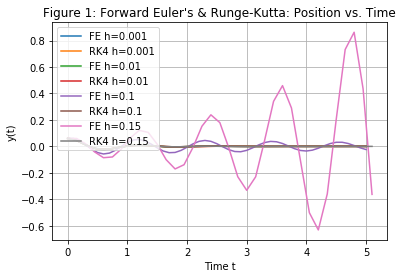

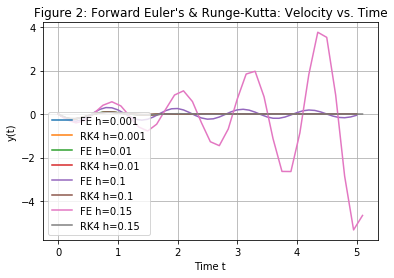

In [11]:
# define function
m = 1292 # mass
c = 4242.658 # damping coefficient
k = 38700 # spring constant

def f(t, y1, y2):
    return -(c/m*y2) - (k/m*y1)

# define parameters
h = np.array([0.001, 0.01, 0.1, 0.15]) # step size
y10 = 0.06 # initial displacement
y20 = 0 # initial velocity
t0 = 0
tf = 5

# implement methods
for i in range(len(h)):
    t_fe, y1_fe, y2_fe = forward_euler(f, y10, y20, t0, tf, h[i])
    t_RK4, y1_RK4, y2_RK4 = runge_kutta_4(f, y10, y20, t0, tf, h[i])
    
    plt.plot(t_fe, y1_fe, label=f'FE h={h[i]}')
    plt.plot(t_RK4, y1_RK4, label=f'RK4 h={h[i]}')
      
# Plot the results
plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Figure 1: Forward Euler\'s & Runge-Kutta: Position vs. Time')
plt.legend(loc='upper left') # citation (2): (Stack Overflow)
plt.grid(True)
plt.show()

for i in range(len(h)):
    t_fe, y1_fe, y2_fe = forward_euler(f, y10, y20, t0, tf, h[i])
    t_RK4, y1_RK4, y2_RK4 = runge_kutta_4(f, y10, y20, t0, tf, h[i])
    
    plt.plot(t_fe, y2_fe, label=f'FE h={h[i]}')
    plt.plot(t_RK4, y2_RK4, label=f'RK4 h={h[i]}')
      
# Plot the results
plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Figure 2: Forward Euler\'s & Runge-Kutta: Velocity vs. Time')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

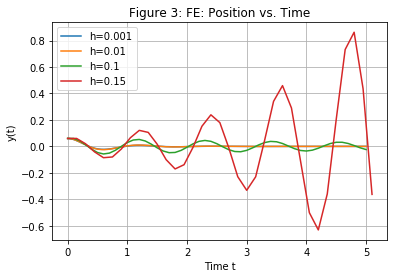

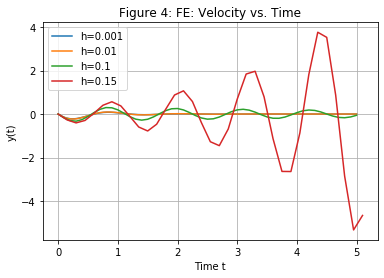

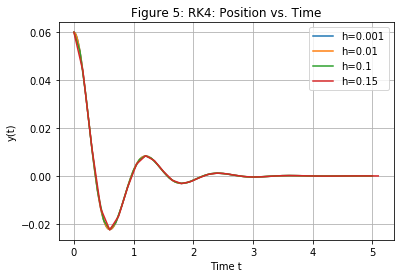

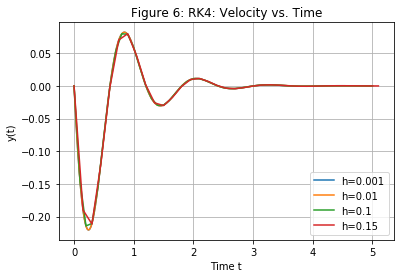

In [12]:
# separate graphs

# Forward Euler's
for i in range(len(h)):
    t_fe, y1_fe, y2_fe = forward_euler(f, y10, y20, t0, tf, h[i])
    plt.plot(t_fe, y1_fe, label=f'h={h[i]}')
# Plot the results
plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Figure 3: FE: Position vs. Time')
plt.legend()
plt.grid(True)
plt.show()

for i in range(len(h)):
    t_fe, y1_fe, y2_fe = forward_euler(f, y10, y20, t0, tf, h[i])
    plt.plot(t_fe, y2_fe, label=f'h={h[i]}')
# Plot the results
plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Figure 4: FE: Velocity vs. Time')
plt.legend()
plt.grid(True)
plt.show()


# RK4
for i in range(len(h)):
    t_RK4, y1_RK4, y2_RK4 = runge_kutta_4(f, y10, y20, t0, tf, h[i])
    plt.plot(t_RK4, y1_RK4, label=f'h={h[i]}')
# Plot the results
plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Figure 5: RK4: Position vs. Time')
plt.legend()
plt.grid(True)
plt.show()

for i in range(len(h)):
    t_RK4, y1_RK4, y2_RK4 = runge_kutta_4(f, y10, y20, t0, tf, h[i])
    plt.plot(t_RK4, y2_RK4, label=f'h={h[i]}')
# Plot the results
plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Figure 6: RK4: Velocity vs. Time')
plt.legend()
plt.grid(True)
plt.show()

For both the position and velocity graphs of the Foward Euler and Runge-Kutta methods, the results are almost identical as the plots match up for stepsizes 0.001 and 0.01, making this approximation reliable in interpreting the function's solution. However, when step size increases to 0.1 and/or 0.15, the Forward Euler's method becomes unstable and the solution diverges, hence the abnormal oscillations of lines "FE h=0.1" and "FE h=0.15."

### 5. Stability Analysis

#### Step-Size Investigation

As step size increases, the method of approximation becomes unstable and the solution accuracy decreases. From the graph of the Forward Euler's method, it is obvious that the solution for $h$ = 0.1 is unstable, demonstrated by the large, uncharacteristic oscillations. On the otherhand, the graphs for RK4 are still stable for the step size paramters; this method is more fit for slightly larger step sizes than Euler's Forward method.

Nontheless, for both methods, the solutions will eventually become unstable as step size increases, as seen in *Figure 7*; these explicit methods of solving differential equations are more suited for small step sizes.

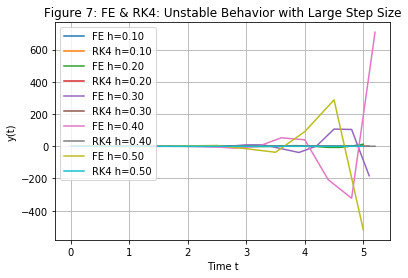

In [4]:
# large step size example

h = np.arange(0.1, 0.6, 0.1)

for i in range(len(h)):
    t_fe, y1_fe, y2_fe = forward_euler(f, y10, y20, t0, tf, h[i])
    t_RK4, y1_RK4, y2_RK4 = runge_kutta_4(f, y10, y20, t0, tf, h[i])

    plt.plot(t_fe, y1_fe, label=f'FE h={h[i]:.2f}')
    plt.plot(t_RK4, y1_RK4, label=f'RK4 h={h[i]:.2f}')
      
# Plot the results
plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Figure 7: FE & RK4: Unstable Behavior with Large Step Size')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

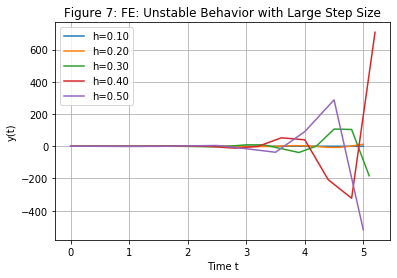

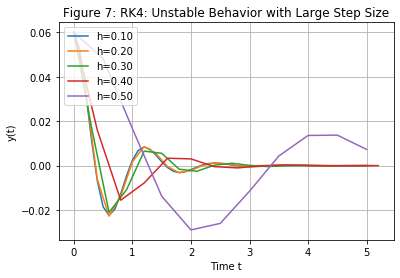

In [5]:
# FE
for i in range(len(h)):
    t_fe, y1_fe, y2_fe = forward_euler(f, y10, y20, t0, tf, h[i])
    plt.plot(t_fe, y1_fe, label=f'h={h[i]:.2f}')

plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Figure 7: FE: Unstable Behavior with Large Step Size')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# RK4
for i in range(len(h)):
    t_RK4, y1_RK4, y2_RK4 = runge_kutta_4(f, y10, y20, t0, tf, h[i])
    plt.plot(t_RK4, y1_RK4, label=f'h={h[i]:.2f}')

plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Figure 7: RK4: Unstable Behavior with Large Step Size')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

The stability condition for Euler's Method $^{(3)}$ requires that
$$h \leq \frac{2}{\sqrt{k}}$$
The spring constant $(k)$ is 38700 N/m; therefore, the maximum stable step size is 0.010167. Step sizes greater than this lead to unstable solutions.

The stability analysis of Runge-Kutta requires using the stability function $R(z)$, where $z = h\lambda$, which must be less than or equal to 1.$^{(4)}$
I calculated the real and imaginary parts of the eigenvalues when I was solving for the function $y(t)$:
    $$\lambda = -1.642 \pm 5.221i$$

In [6]:
# Define the RK4 stability function
def rk4_stability_function(z):
    return 1 + z + (z**2) / 2 + (z**3) / 6 + (z**4) / 24

h = 1 # choose a starting step size

while h>0:
    # Define components of eigenvalue
    real, imag = -1.642, 5.221
    z = (real + 1j * imag) * h

    # Calculate the magnitude of the stability function
    R = rk4_stability_function(z)
    magnitude = np.abs(R)
    
    if magnitude <= 1:
        print("maximum stable step size for RK4 =", h)
        break
    else:
        h -= 0.001

maximum stable step size for RK4 = 0.5179999999999996


#### Error Quantification

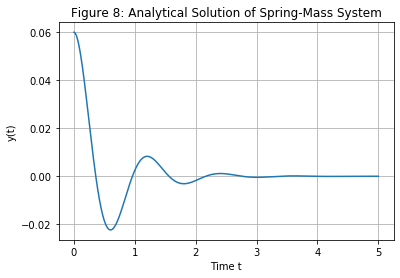

In [7]:
# Analytical Solution
t = np.arange(t0, tf + 0.01, 0.01)
y_exact = 0.06*np.exp(-1.642*t)*np.cos(5.2209*t) + 0.01887*np.exp(-1.642*t)*np.sin(5.2209*t)
'''
    NOTE: I solved the second-order differential equation to get the exact solution,
    and then used y(0) = 0.06 and y'(0) = 0 to find the constants.
'''

plt.plot(t, y_exact)
plt.xlabel("Time t")
plt.ylabel("y(t)")
plt.title("Figure 8: Analytical Solution of Spring-Mass System")
plt.grid(True)
plt.show()

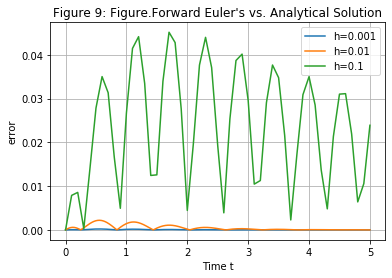

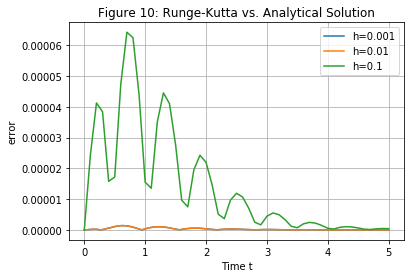

In [8]:
# Approximation Method vs. Analytical Solution
h = np.array([0.001, 0.01, 0.1]) # step size
y10 = 0.06 # initial displacement
y20 = 0 # initial velocity
t0 = 0
tf = 5

# Error of Forward Euler's Method
for i in range(len(h)):
    t, y1_fe, y2_fe = forward_euler(f, y10, y20, t0, tf, h[i])
    y_exact = 0.06*np.exp(-1.642*t)*np.cos(5.2209*t) + 0.01887*np.exp(-1.642*t)*np.sin(5.2209*t)
    error_fe = np.abs(y_exact - y1_fe)
    plt.plot(t, error_fe, label=f'h={h[i]}')
    
# Plot the results
plt.xlabel('Time t')
plt.ylabel('error')
plt.title('Figure 9: Figure.Forward Euler\'s vs. Analytical Solution')
plt.legend()
plt.grid(True)
plt.show()

# Error of Runge-Kutta
for i in range(len(h)):
    t, y1_RK4, y2_RK4 = runge_kutta_4(f, y10, y20, t0, tf, h[i])
    y_exact = 0.06*np.exp(-1.642*t)*np.cos(5.2209*t) + 0.01887*np.exp(-1.642*t)*np.sin(5.2209*t)
    error_RK4 = np.abs(y_exact - y1_RK4)
    plt.plot(t, error_RK4, label=f'h={h[i]}')

# Plot the results
plt.xlabel('Time t')
plt.ylabel('error')
plt.title('Figure 10: Runge-Kutta vs. Analytical Solution')
plt.legend()
plt.grid(True)
plt.show()

In terms of solution accuracy, both methods see a decrease in precision as step size increases, and the Forward Euler's method shows a greater increase in inaccuracy for larger step sizes than Runge-Kutta. This makes sense, because the same argument applies for the instability of these methods, and instability can lead to more errors in numerical methods.

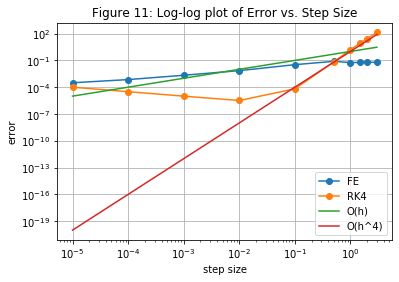

In [9]:
# Error vs. step size
h = np.array([0.00001, 0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 1.5, 2.0, 3.0]) # step size
y10 = 0.06 # initial displacement
y20 = 0 # initial velocity
t0 = 0
tf = 0.5

# Error of Forward Euler's Method
error1 = []
error2 = []
for i in range(len(h)):
    t, y1_fe, y2_fe = forward_euler(f, y10, y20, t0, tf, h[i])
    y_exact = 0.06*np.exp(-1.642*t)*np.cos(5.2209*t) + 0.01887*np.exp(-1.642*t)*np.sin(5.2209*t)
    avgError1 = np.linalg.norm(np.abs(y_exact - y1_fe)) # averaging the errors over the entire set for one step size
    error1.append(avgError1)
    
    t, y1_RK4, y2_RK4 = runge_kutta_4(f, y10, y20, t0, tf, h[i])
    y_exact = 0.06*np.exp(-1.642*t)*np.cos(5.2209*t) + 0.01887*np.exp(-1.642*t)*np.sin(5.2209*t)
    avgError2 = np.linalg.norm(np.abs(y_exact - y1_RK4)) # averaging the errors over the entire set for one step size
    error2.append(avgError2)
    
error_fe = np.array(error1)
error_RK4 = np.array(error2)
    
# Plot the results
plt.loglog(h, error_fe, 'o-', label='FE')
plt.loglog(h, error_RK4, 'o-', label='RK4')
plt.loglog(h, h, label='O(h)')
plt.loglog(h, h**4, label='O(h^4)')
plt.xlabel('step size')
plt.ylabel('error')
plt.title('Figure 11: Log-log plot of Error vs. Step Size')
plt.legend()
plt.grid(True)
plt.show()

Euler's method: O(h) → slope ≈ 1

RK4: O(h⁴) → slope ≈ 4

The slope of line FE, the error of Foward Euler's for each step size, is comparable to the line O(h). The line RK4, the error of Runge-Kutta for each step size, eventually matches the slope of the line O(h^4).

#### Physical Interpretation

Numerical instabilities lead to oscillations in the graphs that are  not representative of the actual behavior of the spring-mass system. For example, as step size increases, the iterative methods become unstable and produce plots with high frequency oscillations and can be seen diverging. However, in reality and as seen by the analytical solution, the oscillations in the graph eventually dampen, reflecting the motion of the spring's displacement eventually returning to equilibrium (where displacement, $y(t)$, is zero). The instability resulting from a large step size produces a solution that continues to grow as time increases, which is not accurate to the physical behavior of this system.

### 6. Conclusion

Overall, the Runge-Kutta method (RK4) performed better for modeling the suspension of a 2003 Volkswagen Beetle as a spring-mass system, although there are some trade-offs. While RK4 is more accurate than Forward Euler's (FE), it is more computationally expensive as it is a fourth order method while FE is first order. RK4 is able to handle larger step sizes than FE, which quickly becomes unstable as h increases. Therefore, computational cost must be sacrificed to increase accuracy and vice versa. RK4 would be my recommendation for practical applications because of its ability to maintain accuracy even with larger step sizes.

### Works Cited

*2003 Volkswagen Beetle Specifications*. (2019). Thecarconnection.com. https://www.thecarconnection.com/specifications/volkswagen_beetle_2003

Avi, A. (2021). Spring Brake | *OptimumG*. Optimumg.com. https://optimumg.com/spring-brake/

Dodamani, S. S., Suresh, C., & D, N. (2016). Design and Fatigue Analysis of McPherson Strut Assembly Coil Spri [Review of *Design and Fatigue Analysis of McPherson Strut Assembly Coil Spri*]. *International Journal of Innovative Research in Science, Engineering and Technology*, 5(7), 13134–13144. https://doi.org/10.15680/IJIRSET.2016.0507187


Hyun, Y. (2005). *The Effect of Suspension Damping on Vehicle Response to Transient Road Inputs*.

*Volkswagen NEW Beetle Convertible 1.6i (102 Hp) | Technical specs, data, fuel consumption, Dimensions*. (2026). Auto-Data.net. https://www.auto-data.net/en/volkswagen-new-beetle-convertible-1.6i-102hp-8800

### Other References

1. *Table 1*
   - searched up in Google "how to make a table in jupyter markdown cells"
   - https://saturncloud.io/blog/tables-in-markdown-in-jupyter/
   
   
2. ```plt.legend(loc=)```
   - searched up in Google "python how to move legends for plots"
   - https://stackoverflow.com/questions/23238041/move-and-resize-legends-box-in-matplotlib


3. stability condition for Euler's Method
   - Canvas lecture slides: Week12-2(Thu): "19.Stability-SecondOrderODEs (2)"
   
   
4. Runge-Kutta, stability function $R(z)$
   - Canvas lecture slides: Week13-1(Tues): "20_RK4"